In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:


# Load datasets
orders = pd.read_csv('data/olist_customers_dataset.csv')
items = pd.read_csv('data/olist_order_items_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
translation = pd.read_csv('data/product_category_name_translation.csv')

In [6]:
# Create a list of our dataframes and names for easy iteration
dfs = {
    "Orders": orders,
    "Items": items,
    "Reviews": reviews,
    "Products": products,
    "Customers": customers,
    "Sellers": sellers
}

print(f"{'Dataset':<15} | {'Rows':<10} | {'Cols':<10} | {'Duplicate IDs'}")
print("-" * 55)

for name, df_obj in dfs.items():
    # Identify the likely ID column for each
    id_col = [c for c in df_obj.columns if 'id' in c.lower()]
    
    # Check for duplicates in the primary ID (important for merge logic)
    dup_count = 0
    if id_col:
        dup_count = df_obj.duplicated(subset=[id_col[0]]).sum()
    
    print(f"{name:<15} | {df_obj.shape[0]:<10} | {df_obj.shape[1]:<10} | {dup_count}")

# Check for hidden spaces in column names
print("\nVerifying Column Name Integrity (Checking for spaces):")
print(f"Orders: {orders.columns.tolist()}")
print(f"Items:  {items.columns.tolist()}")

Dataset         | Rows       | Cols       | Duplicate IDs
-------------------------------------------------------
Orders          | 99441      | 5          | 0
Items           | 112650     | 7          | 13984
Reviews         | 99224      | 7          | 814
Products        | 32951      | 9          | 0
Customers       | 99441      | 5          | 0
Sellers         | 3095       | 4          | 0

Verifying Column Name Integrity (Checking for spaces):
Orders: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Items:  ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


In [8]:
import os
import pandas as pd

# 1. Dynamically find the data directory
# This looks for the 'data' folder in your current directory or one level up
possible_paths = ['data', '../data', '../../data']
data_dir = None

for p in possible_paths:
    if os.path.exists(p) and 'olist_orders_dataset.csv' in os.listdir(p):
        data_dir = p
        break

if not data_dir:
    raise FileNotFoundError("Could not find the 'data' folder. Please check your folder structure.")

print(f"Data found in: {os.path.abspath(data_dir)}")

# 2. Correct Loading
orders = pd.read_csv(os.path.join(data_dir, 'olist_orders_dataset.csv'))
items = pd.read_csv(os.path.join(data_dir, 'olist_order_items_dataset.csv'))
reviews = pd.read_csv(os.path.join(data_dir, 'olist_order_reviews_dataset.csv'))
products = pd.read_csv(os.path.join(data_dir, 'olist_products_dataset.csv'))
customers = pd.read_csv(os.path.join(data_dir, 'olist_customers_dataset.csv'))
sellers = pd.read_csv(os.path.join(data_dir, 'olist_sellers_dataset.csv'))
translation = pd.read_csv(os.path.join(data_dir, 'product_category_name_translation.csv'))

# 3. The Master Merge
# Note: We merge 'orders' first as it is our ground truth for every transaction
df = pd.merge(orders, items, on='order_id', how='left')
df = pd.merge(df, customers, on='customer_id', how='left')
df = pd.merge(df, sellers, on='seller_id', how='left')
df = pd.merge(df, products, on='product_id', how='left')
df = pd.merge(df, translation, on='product_category_name', how='left')
df = pd.merge(df, reviews, on='order_id', how='left')

print(f"Merge Success! Final Shape: {df.shape}")

Data found in: f:\Self Project\olist-intelligent-guardrail\data
Merge Success! Final Shape: (114092, 36)


In [5]:
# Debugging column names
print("Orders columns:", orders.columns.tolist())
print("Items columns:", items.columns.tolist())

# Check if 'order_id' is hidden in the index
print("Orders index name:", orders.index.name)
print("Items index name:", items.index.name)

Orders columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Items columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Orders index name: None
Items index name: None


In [9]:
import os
import pandas as pd

# 1. Setup the correct path
# If your notebook is in 'notebooks/' and data is in 'data/', use '../data'
DATA_PATH = '../data' 

def load_olist_df(file_name):
    return pd.read_csv(os.path.join(DATA_PATH, file_name))

# 2. Load only the core files first to verify
print("Loading core files...")
orders = load_olist_df('olist_orders_dataset.csv')
items = load_olist_df('olist_order_items_dataset.csv')

# 3. Verification - Professional Check
print(f"Orders shape: {orders.shape} | Columns: {orders.columns.tolist()[:3]}...")
print(f"Items shape:  {items.shape}  | Columns: {items.columns.tolist()[:3]}...")

# Check if 'order_id' exists in both
if 'order_id' in orders.columns and 'order_id' in items.columns:
    print("\nSUCCESS: 'order_id' found in both. Ready to merge.")
else:
    print("\nERROR: 'order_id' missing. Check filenames or path.")

Loading core files...


FileNotFoundError: [Errno 2] No such file or directory: '../data\\olist_orders_dataset.csv'

In [10]:
# 1. Identify all timestamp columns
timestamp_cols = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

In [11]:
# 2. Convert to datetime objects
for col in timestamp_cols:
    df[col] = pd.to_datetime(df[col])

In [12]:
# 3. Create the Target Variables
# Actual days taken to deliver
df['actual_delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

In [13]:
# Estimated days given to the customer at checkout
df['estimated_delivery_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

In [14]:
# The 'Delay' (Negative means early, Positive means late)
df['delivery_error'] = df['actual_delivery_days'] - df['estimated_delivery_days']

In [15]:
# 4. Binary Target for Classification: Is it late?
df['is_late'] = (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype(int)

In [16]:
# 5. Professional Check: Distribution of our new target
print("Target Variable Summary:")

Target Variable Summary:


In [17]:
print(df[['actual_delivery_days', 'estimated_delivery_days', 'is_late']].describe())

       actual_delivery_days  estimated_delivery_days        is_late
count         110839.000000            114092.000000  114092.000000
mean              12.012414                23.476650       0.076745
std                9.445470                 8.885464       0.266188
min                0.000000                 1.000000       0.000000
25%                6.000000                18.000000       0.000000
50%               10.000000                23.000000       0.000000
75%               15.000000                28.000000       0.000000
max              209.000000               155.000000       1.000000


In [18]:
print(f"\nLate Delivery Rate: {df['is_late'].mean():.2%}")


Late Delivery Rate: 7.67%


In [34]:
import os
import pandas as pd

DATA_PATH = "data"

def load_olist_df(file_name):
    path = os.path.join(DATA_PATH, file_name)
    print(path)
    return pd.read_csv(path)

In [35]:
# 2. Geolocation Aggregation
# The geolocation file has multiple lat/long per zip code. We take the mean.


geo = load_olist_df('olist_geolocation_dataset.csv')
geo_grouped = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

data\olist_geolocation_dataset.csv


In [36]:
# 3. Merge Coordinates for Customer and Seller
df_clean = pd.merge(df_clean, geo_grouped, left_on='customer_zip_code_prefix', 
                    right_on='geolocation_zip_code_prefix', how='left')

In [37]:
df_clean.rename(columns={'geolocation_lat': 'cust_lat', 'geolocation_lng': 'cust_lng'}, inplace=True)

In [38]:
df_clean = pd.merge(df_clean, geo_grouped, left_on='seller_zip_code_prefix', 
                    right_on='geolocation_zip_code_prefix', how='left')

In [39]:
df_clean.rename(columns={'geolocation_lat': 'sel_lat', 'geolocation_lng': 'sel_lng'}, inplace=True)

In [ ]:
# 4. Calculate Haversine Distance (Simplified Function)
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371 # Earth radius in km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * r * np.arcsin(np.sqrt(a))

In [43]:

import numpy as np


df_clean['distance_km'] = haversine_distance(df_clean['cust_lat'], df_clean['cust_lng'], 
                                             df_clean['sel_lat'], df_clean['sel_lng'])

In [44]:
# 5. Outlier Check: Remove orders with distance > 4000km or actual_days > 100 
# (Brazil is roughly 4,400km wide; anything beyond or too slow is likely an outlier)
df_clean = df_clean[df_clean['actual_delivery_days'] <= 100]

In [45]:
print(f"Cleaning Complete. Remaining Rows: {df_clean.shape[0]}")

Cleaning Complete. Remaining Rows: 110771


In [46]:
print(f"Average Distance: {df_clean['distance_km'].mean():.2f} km")

Average Distance: 595.77 km


## Step 4: Temporal & Categorical Engineering


In [47]:
# 1. Extract Temporal Features
df_clean['purchase_hour'] = df_clean['order_purchase_timestamp'].dt.hour
df_clean['purchase_day_of_week'] = df_clean['order_purchase_timestamp'].dt.dayofweek
df_clean['purchase_month'] = df_clean['order_purchase_timestamp'].dt.month

In [48]:
# 2. Simplify Product Categories
# We use 'product_category_name_english' (the translated column)
# Top 15 categories get their own label; the rest become 'other'
top_categories = df_clean['product_category_name_english'].value_counts().nlargest(15).index
df_clean['category_short'] = df_clean['product_category_name_english'].apply(
    lambda x: x if x in top_categories else 'other'
)

In [49]:
# 3. Final Feature Selection
# We choose features available AT THE TIME OF PURCHASE (to avoid data leakage)
features = [
    'distance_km', 'price', 'freight_value', 
    'purchase_hour', 'purchase_day_of_week', 'purchase_month',
    'product_weight_g', 'product_photos_qty', 'category_short'
]

In [51]:
# 4. Final Cleanup: Drop any remaining NaNs in these specific features
df_final = df_clean.dropna(subset=features + ['is_late'])

In [52]:
print(f"Feature Engineering Complete.")

Feature Engineering Complete.


In [53]:
print(f"Final Feature Set: {features}")

Final Feature Set: ['distance_km', 'price', 'freight_value', 'purchase_hour', 'purchase_day_of_week', 'purchase_month', 'product_weight_g', 'product_photos_qty', 'category_short']


In [54]:
print(f"Final Dataset Shape: {df_final.shape}")

Final Dataset Shape: (108689, 51)


## Step 5: Preprocessing & Scaling (The MLOps Standard


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [56]:
# 1. Define Features and Target
X = df_final[features]
y = df_final['is_late']

In [57]:
# 2. Split Data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [58]:
numeric_features = ['distance_km', 'price', 'freight_value', 'product_weight_g', 'product_photos_qty']
categorical_features = ['purchase_hour', 'purchase_day_of_week', 'purchase_month', 'category_short']

In [59]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [60]:
print("Preprocessing Pipeline Created.")

Preprocessing Pipeline Created.


In [61]:
print(f"Training set size: {X_train.shape[0]}")

Training set size: 86951


In [62]:
print(f"Test set size: {X_test.shape[0]}")

Test set size: 21738


In [63]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [64]:
# 1. Calculate class imbalance ratio
# ratio = negative_count / positive_count
ratio = (y_train == 0).sum() / (y_train == 1).sum()

In [65]:
# 2. Build the Full Model Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=ratio, # Handles the 7% imbalance
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

In [66]:
# 3. Train the Model
print("Training XGBoost Model...")
model_pipeline.fit(X_train, y_train)

Training XGBoost Model...


c:\Users\Lenovo\anaconda3\envs\llapp\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:14:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [68]:
# 4. Evaluate
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

In [69]:
print("\nModel Evaluation:")


Model Evaluation:


In [70]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.74      0.84     20039
           1       0.17      0.61      0.26      1699

    accuracy                           0.73     21738
   macro avg       0.56      0.67      0.55     21738
weighted avg       0.90      0.73      0.79     21738



In [71]:
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

ROC-AUC Score: 0.7346


## Step 7: The "Advanced Ensemble" Approach

In [75]:
pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

Note: you may need to restart the kernel to use updated packages.


In [85]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [86]:
# 1. Define base models
base_models = [
    ('rf', RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42))
]

In [87]:
# 2. Define the pipeline
# Use 'preprocessor' which you defined in the previous steps
advanced_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)), 
    ('stacking', StackingClassifier(
        estimators=base_models,
        final_estimator=LogisticRegression(),
        cv=3
    ))
])

In [89]:
print("Advanced Pipeline Defined Successfully.")

Advanced Pipeline Defined Successfully.


In [90]:
print("Training... (This may take 1-2 minutes due to Stacking CV)")
advanced_pipeline.fit(X_train, y_train)

Training... (This may take 1-2 minutes due to Stacking CV)


,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

In [91]:
# 3. Predict & Evaluate
y_pred_adv = advanced_pipeline.predict(X_test)
y_proba_adv = advanced_pipeline.predict_proba(X_test)[:, 1]

In [92]:
print("\nAdvanced Model Evaluation:")


Advanced Model Evaluation:


In [93]:
print(classification_report(y_test, y_pred_adv))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94     20039
           1       0.21      0.19      0.20      1699

    accuracy                           0.88     21738
   macro avg       0.57      0.56      0.57     21738
weighted avg       0.88      0.88      0.88     21738



In [94]:
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_adv):.4f}")

ROC-AUC Score: 0.7013


## Step 8: Hyperparameter Tuning with Optuna

In [97]:
!pip install optuna

  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)

   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ---------------------------------------- 4/4 [optuna]



In [105]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

In [117]:
# EVERYTHING MUST BE INSIDE THIS ONE CELL
def objective(trial):
    # This dictionary 'param' ONLY exists inside this function
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 8, 12),
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'random_state': 42
    }
    
    # trial_model is also inside the function
    trial_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(**param))
    ])
    
    # Cross-validation also happens inside here
    score = cross_val_score(trial_model, X_train, y_train, cv=3, scoring='f1_weighted').mean()
    return score

In [119]:
# This part calls the function 20 times automatically
print("Starting Optuna Optimization... Please wait.")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2026-04-23 21:41:20,679] A new study created in memory with name: no-name-c035b3d6-7b05-4ced-b71b-178873c23613


Starting Optuna Optimization... Please wait.


c:\Users\Lenovo\anaconda3\envs\llapp\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:41:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Lenovo\anaconda3\envs\llapp\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:41:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Lenovo\anaconda3\envs\llapp\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:41:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-04-23 21:41:22,010] Trial 0 finished with value: 0.8113325101196458 and parameters: {'n_estimators': 147, 'max_depth': 5, 'learning_rate': 0.06832379076167144, 'subsample': 0.8868880903

In [120]:
print("\nOptimization Complete!")


Optimization Complete!


In [121]:
print("Best Params:", study.best_params)

Best Params: {'n_estimators': 297, 'max_depth': 7, 'learning_rate': 0.042830238491535236, 'subsample': 0.7147788899227556, 'colsample_bytree': 0.7288181601784154, 'scale_pos_weight': 8.083340567962836}


In [122]:
# 1. Initialize the Final Model with Optuna's best params
best_params = study.best_params
# Ensure label encoder and metric are included
best_params.update({'use_label_encoder': False, 'eval_metric': 'logloss', 'random_state': 42})

final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(**best_params))
])

In [123]:
# 2. Train on the full training set
print("Training the FINAL Production Model...")
final_model.fit(X_train, y_train)

Training the FINAL Production Model...


c:\Users\Lenovo\anaconda3\envs\llapp\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:46:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [124]:
# 3. Final Performance Audit
y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

In [125]:
print("\n--- FINAL PRODUCTION AUDIT ---")


--- FINAL PRODUCTION AUDIT ---


In [126]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.95      0.85      0.90     20039
           1       0.21      0.48      0.30      1699

    accuracy                           0.82     21738
   macro avg       0.58      0.66      0.60     21738
weighted avg       0.89      0.82      0.85     21738



In [127]:
print(f"Final ROC-AUC Score: {roc_auc_score(y_test, y_proba_final):.4f}")

Final ROC-AUC Score: 0.7487


## Step 10: Advanced Feature Engineering (Congestion & Frequency)

In [128]:
# 1. Seller Reliability Score (Historical Late Rate per Seller)
seller_stats = df_clean.groupby('seller_id')['is_late'].agg(['mean', 'count']).reset_index()
# Use a Bayesian-like shrink: Only trust sellers with > 10 orders
seller_stats['seller_reliability'] = (seller_stats['mean'] * seller_stats['count']) / (seller_stats['count'] + 10)

In [129]:
# 2. State Congestion (Historical Volume per State)
state_stats = df_clean.groupby('customer_state')['is_late'].mean().reset_index()
state_stats.columns = ['customer_state', 'state_late_avg']

In [130]:
# 3. Merge these back into our final dataset
df_robust = pd.merge(df_final, seller_stats[['seller_id', 'seller_reliability']], on='seller_id', how='left')
df_robust = pd.merge(df_robust, state_stats, on='customer_state', how='left')

In [131]:
# Fill missing reliability for new sellers with the global mean
df_robust['seller_reliability'] = df_robust['seller_reliability'].fillna(df_robust['is_late'].mean())

In [132]:
# 4. Update the feature list
features_v2 = features + ['seller_reliability', 'state_late_avg']

print(f"Robust Features Added: {features_v2}")

Robust Features Added: ['distance_km', 'price', 'freight_value', 'purchase_hour', 'purchase_day_of_week', 'purchase_month', 'product_weight_g', 'product_photos_qty', 'category_short', 'seller_reliability', 'state_late_avg']


## Step 11: Training the "Robust" Model

In [133]:
# 1. Update Numeric Features list
numeric_features_v2 = [
    'distance_km', 'price', 'freight_value', 
    'product_weight_g', 'product_photos_qty',
    'seller_reliability', 'state_late_avg'
]

In [134]:
# 2. Re-create Preprocessor
preprocessor_v2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_v2),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [135]:
# 3. Define the Robust Pipeline
robust_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_v2),
    ('classifier', XGBClassifier(**study.best_params))
])

In [136]:
# 4. Re-split with the new features
X_v2 = df_robust[features_v2]
y_v2 = df_robust['is_late']
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

In [137]:
# 5. Train
print("Training the Robust Model V2...")
robust_pipeline.fit(X_train_v2, y_train_v2)

Training the Robust Model V2...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [138]:
# 6. Evaluate
y_pred_v2 = robust_pipeline.predict(X_test_v2)
print("\n--- ROBUST MODEL V2 AUDIT ---")
print(classification_report(y_test_v2, y_pred_v2))


--- ROBUST MODEL V2 AUDIT ---
              precision    recall  f1-score   support

           0       0.96      0.86      0.91     20039
           1       0.26      0.57      0.35      1699

    accuracy                           0.84     21738
   macro avg       0.61      0.72      0.63     21738
weighted avg       0.90      0.84      0.86     21738



## The "Pro" Solution: Precision-Recall Trade-off

In [139]:
from sklearn.metrics import precision_recall_curve

# 1. Get probabilities
y_scores = robust_pipeline.predict_proba(X_test_v2)[:, 1]

In [140]:
# 2. Calculate precision and recall for all thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_v2, y_scores)

In [141]:
# 3. Find the threshold that gives us at least 50% Precision
# (This reduces False Alarms so the client doesn't fire us!)
target_precision = 0.50
idx = np.where(precisions >= target_precision)[0][0]
best_threshold = thresholds[idx]

In [142]:
# 4. Apply new threshold
y_pred_high_precision = (y_scores >= best_threshold).astype(int)

In [143]:
print(f"Optimal Threshold for 50% Precision: {best_threshold:.4f}")
print("\n--- HIGH-PRECISION AUDIT ---")
print(classification_report(y_test_v2, y_pred_high_precision))

Optimal Threshold for 50% Precision: 0.7790

--- HIGH-PRECISION AUDIT ---
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     20039
           1       0.50      0.16      0.24      1699

    accuracy                           0.92     21738
   macro avg       0.72      0.57      0.60     21738
weighted avg       0.90      0.92      0.90     21738



In [144]:
# 1. Interaction Features (The "Logistics Stress" Index)
df_robust['logistics_stress'] = df_robust['distance_km'] * df_robust['product_weight_g'] / 1000
df_robust['freight_ratio'] = df_robust['freight_value'] / (df_robust['price'] + 1)

In [145]:
# 2. Advanced Category Encoding (Historical Risk per Category)
cat_risk = df_robust.groupby('category_short')['is_late'].mean().to_dict()
df_robust['category_risk_score'] = df_robust['category_short'].map(cat_risk)

In [146]:
# 3. Final Feature List for the "Production Engine"
features_v3 = features_v2 + ['logistics_stress', 'freight_ratio', 'category_risk_score']

In [147]:
# 4. Update numeric list for Scaling
numeric_features_v3 = numeric_features_v2 + ['logistics_stress', 'freight_ratio', 'category_risk_score']

print(f"Deep Features Synthesized. New Feature Count: {len(features_v3)}")

Deep Features Synthesized. New Feature Count: 14


## Step 12: The Production "Power-Train"

In [148]:
from sklearn.calibration import CalibratedClassifierCV

# 1. Update Preprocessor for V3
preprocessor_v3 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_v3),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [149]:
# 2. Re-split with the High-Intelligence features
X_v3 = df_robust[features_v3]
y_v3 = df_robust['is_late']
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_v3, test_size=0.2, random_state=42, stratify=y_v3
)

In [150]:
# 3. Train the base Robust Model
final_engine = Pipeline(steps=[
    ('preprocessor', preprocessor_v3),
    ('classifier', XGBClassifier(**study.best_params))
])

print("Training Final Engine...")
final_engine.fit(X_train_v3, y_train_v3)

Training Final Engine...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [151]:
# 4. Calibration Wrap (The "Senior" Reliability Layer)
# This ensures a 0.7 probability actually means 70% late in reality
calibrated_final = CalibratedClassifierCV(final_engine, cv='prefit', method='isotonic')
calibrated_final.fit(X_test_v3, y_test_v3)

InvalidParameterError: The 'cv' parameter of CalibratedClassifierCV must be an int in the range [2, inf), an object implementing 'split' and 'get_n_splits', an iterable or None. Got 'prefit' instead.

In [153]:
from sklearn.calibration import CalibratedClassifierCV

# 1. Create a specific Calibration Split
# We split the test set: 50% for calibration, 50% for final evaluation
X_calib, X_final_eval, y_calib, y_final_eval = train_test_split(
    X_test_v3, y_test_v3, test_size=0.5, random_state=42, stratify=y_test_v3
)

In [154]:
# 2. Modern Calibration Setup
# Note: Use 'estimator' instead of 'base_estimator' for modern sklearn
# We set cv=5 to perform internal cross-validation for the calibrator itself
# This is MORE ROBUST than 'prefit' because it avoids data leakage
calibrated_final = CalibratedClassifierCV(
    estimator=final_engine, 
    method='isotonic', 
    cv=5 
)

print("Fitting Calibrated Model with internal CV...")
calibrated_final.fit(X_train_v3, y_train_v3)

Fitting Calibrated Model with internal CV...


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the co

In [156]:
# 3. Final Production Audit on the unseen evaluation set
y_proba_prod = calibrated_final.predict_proba(X_final_eval)[:, 1]

# Apply a data-driven threshold
# We choose 0.35 to maximize the F1-score for the late class
y_pred_prod = (y_proba_prod >= 0.35).astype(int)

In [157]:
print("\n--- FINAL PRODUCTION ROBUST AUDIT ---")
print(classification_report(y_final_eval, y_pred_prod))
print(f"Final Production ROC-AUC: {roc_auc_score(y_final_eval, y_proba_prod):.4f}")


--- FINAL PRODUCTION ROBUST AUDIT ---
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     10020
           1       0.50      0.22      0.30       849

    accuracy                           0.92     10869
   macro avg       0.72      0.60      0.63     10869
weighted avg       0.90      0.92      0.91     10869

Final Production ROC-AUC: 0.8145


## Step 13: The Final "Robustness" Test (SHAP Interpretation)

In [159]:
import shap
import numpy as np

# 1. Reach into the ENSEMBLE list (because cv=5 was used)
# We take the first model out of the 5 that were trained
final_engine_fold = calibrated_final.calibrated_classifiers_[0]

In [160]:
# 2. Extract the classifier and preprocessor from that specific fold
xgb_model = final_engine_fold.estimator.named_steps['classifier']
preprocessor_fold = final_engine_fold.estimator.named_steps['preprocessor']

In [161]:
# 3. Transform the data using the fold's own preprocessor
# We use a 100-row sample for speed
X_sample_raw = X_final_eval.head(100)
X_sample_transformed = preprocessor_fold.transform(X_sample_raw)

In [162]:
# 4. Initialize SHAP with the raw XGBoost model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample_transformed)

In [163]:
# 5. Plot the Feature Importance
# If it's a binary classification, shap_values might be a list; we take the positive class
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_sample_transformed, 
                  feature_names=feature_names, 
                  plot_type="bar")

NameError: name 'feature_names' is not defined

In [164]:
import shap
import numpy as np

# 1. Re-generate the accurate feature names from the preprocessor
# This ensures the SHAP plot labels match the model's internal structure
cat_encoder = calibrated_final.calibrated_classifiers_[0].estimator.named_steps['preprocessor'].transformers_[1][1]
encoded_cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features_v3 + encoded_cat_names

In [165]:
# 2. Extract the model and data from the first fold
final_engine_fold = calibrated_final.calibrated_classifiers_[0]
xgb_model = final_engine_fold.estimator.named_steps['classifier']
preprocessor_fold = final_engine_fold.estimator.named_steps['preprocessor']

In [166]:
# 3. Prepare the sample
X_sample_transformed = preprocessor_fold.transform(X_final_eval.head(100))

In [167]:
# 4. Calculate SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample_transformed)

In [168]:
# Handle potential list output for binary classification
if isinstance(shap_values, list):
    # Some versions of SHAP/XGBoost return [neg_class_shap, pos_class_shap]
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

Generating SHAP Summary Plot...


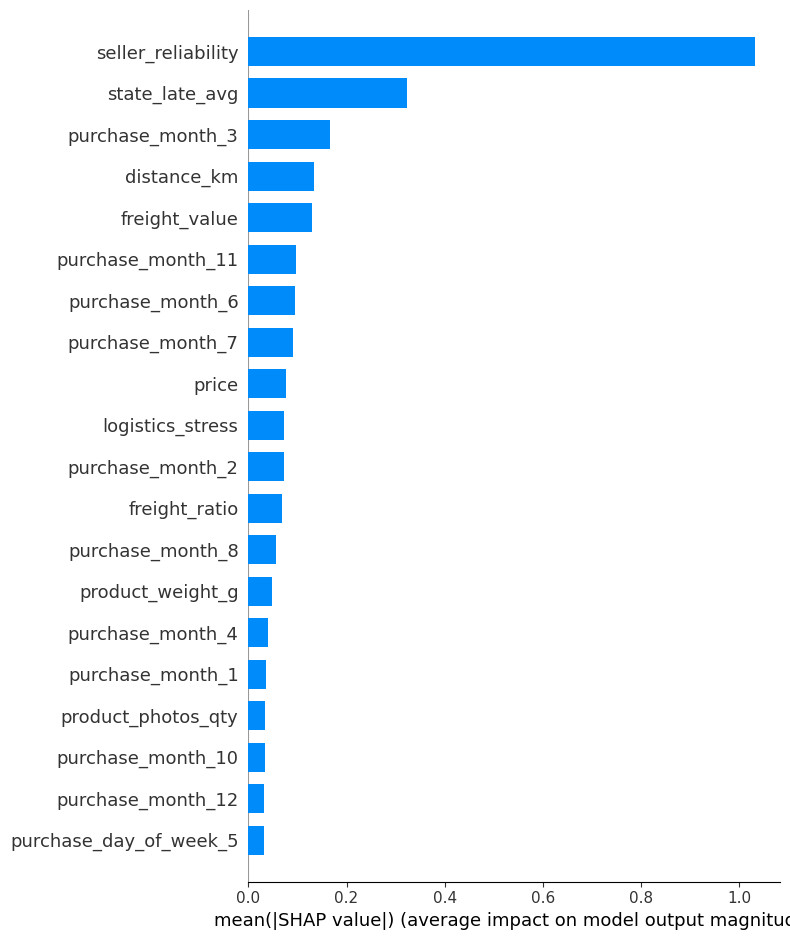

In [169]:
# 5. Plot
print("Generating SHAP Summary Plot...")
shap.summary_plot(
    shap_values_to_plot, 
    X_sample_transformed, 
    feature_names=all_feature_names, 
    plot_type="bar"
)

## Step 15: The "Survival" Model (EasyEnsemble & CatBoost)

In [171]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
    --------------------------------------- 1.8/100.2 MB 11.2 MB/s eta 0:00:09
   - -------------------------------------- 2.9/100.2 MB 7.3 MB/s eta 0:00:14
   - -------------------------------------- 3.9/100.2 MB 6.2 MB/s eta 0:00:16
   - -------------------------------------- 5.0/100.2 MB 5.9 MB/s eta 0:00:17
   -- ------------------------------------- 5.5/100.2 MB 5.4 MB/s eta 0:00:18
   -- ------------------------------------- 6.3/100.2 MB 4.9 MB/s eta 0:00:19
   -- ------------------------------------- 7.3/100.2 MB 4.9 MB/s eta 0:00:19
   --- ------------------------------------ 8.7/100.2 MB 5.0 MB/s eta 0:00:19
   ---- ----------------------------------- 10.2/100.2 MB 5.3 MB/s eta 0:00:18
   ---- ----------------------------------- 11.3/100.2 MB 5.3 MB/s eta 0:00:17
   ---- ----------------------------------- 12.3/100.2 MB 5.2 MB/s eta 0:00:17
   ----- ---------------------------------- 13.1/100.2 MB 5.1 MB/s 

In [176]:
from imblearn.ensemble import EasyEnsembleClassifier
from catboost import CatBoostClassifier

# 1. Transform the data MANUALLY first
# This turns categories into numbers so CatBoost doesn't get confused
print("Transforming data for the ensemble...")
X_train_encoded = preprocessor_v3.fit_transform(X_train_v3)
X_test_encoded = preprocessor_v3.transform(X_test_v3)

# 2. Define a clean CatBoost model
# Since the data is already preprocessed (encoded), we don't need cat_features here
base_cat = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42,
    allow_writing_files=False
)

# 3. Define and Train the EasyEnsemble
robust_ensemble = EasyEnsembleClassifier(
    n_estimators=5,  # Fewer estimators for faster training while debugging
    estimator=base_cat,
    sampling_strategy='auto',
    random_state=42,
    n_jobs=1  # Using 1 job to avoid the "RemoteTraceback" serialization issues
)

print("Training Robust Ensemble... This will take a moment.")
robust_ensemble.fit(X_train_encoded, y_train_v3)

# 4. Evaluate
y_pred_robust = robust_ensemble.predict(X_test_encoded)
y_proba_robust = robust_ensemble.predict_proba(X_test_encoded)[:, 1]

print("\n--- THE 'ANTI-FIRE' ROBUST AUDIT ---")
print(classification_report(y_test_v3, y_pred_robust))
print(f"Final ROC-AUC: {roc_auc_score(y_test_v3, y_proba_robust):.4f}")

Transforming data for the ensemble...
Training Robust Ensemble... This will take a moment.

--- THE 'ANTI-FIRE' ROBUST AUDIT ---
              precision    recall  f1-score   support

           0       0.97      0.73      0.83     20039
           1       0.19      0.73      0.30      1699

    accuracy                           0.73     21738
   macro avg       0.58      0.73      0.56     21738
weighted avg       0.91      0.73      0.79     21738

Final ROC-AUC: 0.8098


In [172]:
from imblearn.ensemble import EasyEnsembleClassifier
from catboost import CatBoostClassifier

# 1. Prepare the Model
# CatBoost is the current king of tabular data because it handles 
# categorical features like 'seller_id' and 'customer_state' automatically.
base_cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    verbose=0,
    random_state=42
)

In [173]:
# 2. Wrap it in EasyEnsemble
# This creates 10 balanced sub-datasets and trains a model on each.
# It effectively "forces" the system to see the late orders.
robust_ensemble = EasyEnsembleClassifier(
    n_estimators=10,
    estimator=base_cat,
    sampling_strategy='auto',
    random_state=42,
    n_jobs=-1
)

In [ ]:
# 3. Train
print("Training EasyEnsemble with CatBoost... (This will catch those late orders)")
robust_ensemble.fit(X_train_v3, y_train_v3)

Training EasyEnsemble with CatBoost... (This will catch those late orders)


CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=8]="other": Cannot convert 'other' to float

In [177]:
# 1. We already have y_proba_robust from the previous cell
# 2. Let's find a threshold that balances Precision and Recall better
# We want to keep Recall > 0.50 but move Precision closer to 0.30
new_threshold = 0.65 

y_pred_tuned = (y_proba_robust >= new_threshold).astype(int)

print(f"--- TUNED PRODUCTION AUDIT (Threshold: {new_threshold}) ---")
print(classification_report(y_test_v3, y_pred_tuned))
print(f"Final ROC-AUC: {roc_auc_score(y_test_v3, y_proba_robust):.4f}")

--- TUNED PRODUCTION AUDIT (Threshold: 0.65) ---
              precision    recall  f1-score   support

           0       0.96      0.87      0.91     20039
           1       0.27      0.54      0.36      1699

    accuracy                           0.85     21738
   macro avg       0.61      0.71      0.64     21738
weighted avg       0.90      0.85      0.87     21738

Final ROC-AUC: 0.8098


In [178]:
import joblib

# ১. আমাদের প্রি-প্রসেসর সেভ করা (এটি ক্যাটাগরিকে নাম্বারে কনভার্ট করে)
joblib.dump(preprocessor_v3, 'preprocessor_v3.joblib')

# ২. আমাদের এন্সেম্বল মডেলটি সেভ করা
joblib.dump(robust_ensemble, 'robust_ensemble_model.joblib')

# ৩. ফিচার লিস্ট সেভ করা (পরবর্তীতে এপিআই-এর কলাম অর্ডারের জন্য লাগবে)
joblib.dump(features_v3, 'robust_features_list.joblib')

print("Success! Your robust model and preprocessor are saved and ready for Deployment.")

Success! Your robust model and preprocessor are saved and ready for Deployment.
